# Unsupervised Learning (I): Clustering

<div class='alert alert-info'>

:::{objectives}
- Explain what unsupervised learning is and how clustering fits into it.
- Understand main ideas behind centroid-based (K-Means), hierarchical, density-based (DBSCAN), model-based (GMM), and graph-based (Spectral Clustering) methods.
- Apply representative clustering algorithms in practice.
- Understand how to evaluate clustering quality using confusion matrices, silhouette scores, or visualizations.
:::
</div>

<div class='alert alert-success'>

:::{instructor-note}
- 40 min teaching/demonstration
- 40 min exercises
:::
</div>

## 0. Unsupervised Learning

In episodes [Supervised Learning (I): Classification](./5-classification.ipynb) and [Supervised Learning (II): Regression](./6-regression.ipynb), we have explored supervised learning, where each training example includes both input features and the corresponding output. This setup enables the models to learn a direct mapping from inputs to targets. For the Penguins dataset, both classification and regression models, such as logistic/linear regression, decision trees, and neural networks, were applied to either classify penguin species or predict body mass based on flipper length.

It is important to emphasize that **supervised learning depends heavily on labeled data**, which may not always be available in real-world scenarios. Collecting labeled data can be expensive, time-consuming, or even impossible. In such cases, we turn to **unsupervised learning to uncover patterns and structure in dataset**.

In unsupervised learning, the dataset contains only the input features without associated labels. The goal is to discover hidden patterns, structures within the data, and derive insights without explicit supervision. Unsupervised learning is essential for analyzing the vast amounts of raw data generated in real-world applications, from scientific research to business intelligence. Its significance can be seen across several key areas:
- **Exploratory Data Analysis** (**EDA**): Techniques such as clustering and dimensionality reduction are fundamental for understanding the structure of complex datasets. They can reveal natural groupings, trends, and correlations that might otherwise remain hidden, providing a crucial first step in any data-driven investigation.
- **Anomaly Detection**: Unsupervised learning is vital for maintaining security and operational integrity. By modeling “normal” behavior, algorithms can identify unusual patterns, such as fraudulent financial transactions, network intrusions, or rare mechanical failures, without needing labeled examples of every type of anomaly.
- **Feature Engineering** and **Representation Learning**: Methods like **Principal Component Analysis** (PCA) can compress data into its most informative components, reducing noise and improving the efficiency and performance of downstream supervised models.

In this and the following episodes, we will apply **Clustering** and **Dimensionality Reduction** methods on the Penguins dataset to explore its underlying structure and uncover hidden patterns without the guidance of pre-existing labels. By employing clustering methods like K-means, we aim to identify species-specific clusters or other biologically meaningful subgroups among Adelie, Gentoo, and Chinstrap penguins. Additionally, dimensionality reduction techniques like PCA will simplify the dataset’s feature space, enabling visualization of complex relationships and enhancing subsequent analyses. These approaches will deepen our understanding of penguin characteristics, reveal outliers, and complement supervised methods by providing a robust framework for exploratory data analysis.

## 1. Clustering

Clustering is one of most widely used techniques in unsupervised learning
- it aims to organize data into groups, or clusters, based on similarity
    - grouping of documents, music, and movies by different topics
    - finding customers that share similar interests based on common purchase behaviors as a basis for recommendation engines
- in real-world applications of clustering, we do not have any ground truth category information about samples
- instead, algorithm analyzes patterns and structures within dataset to discover natural groupings

One of the most fundamental challenges of clustering is determining optimal number of clusters (*k*), which is often non-trivial
- many algorithms, such as K-Means, require specifying number of clusters in advance, which may not be immediately obvious from data
- as illustrated in figure below, data could be grouped into two, three, or four clusters, depending on level of granularity chosen
    - selecting too few clusters may oversimplify structure and miss important patterns, while choosing too many clusters can lead to overfitting, where random noise is mistaken for meaningful structures
- in addition, quality and scale of features also have a significant impact on clustering results
    - features with larger scales can dominate distance computations, making preprocessing steps such as standardization essential.

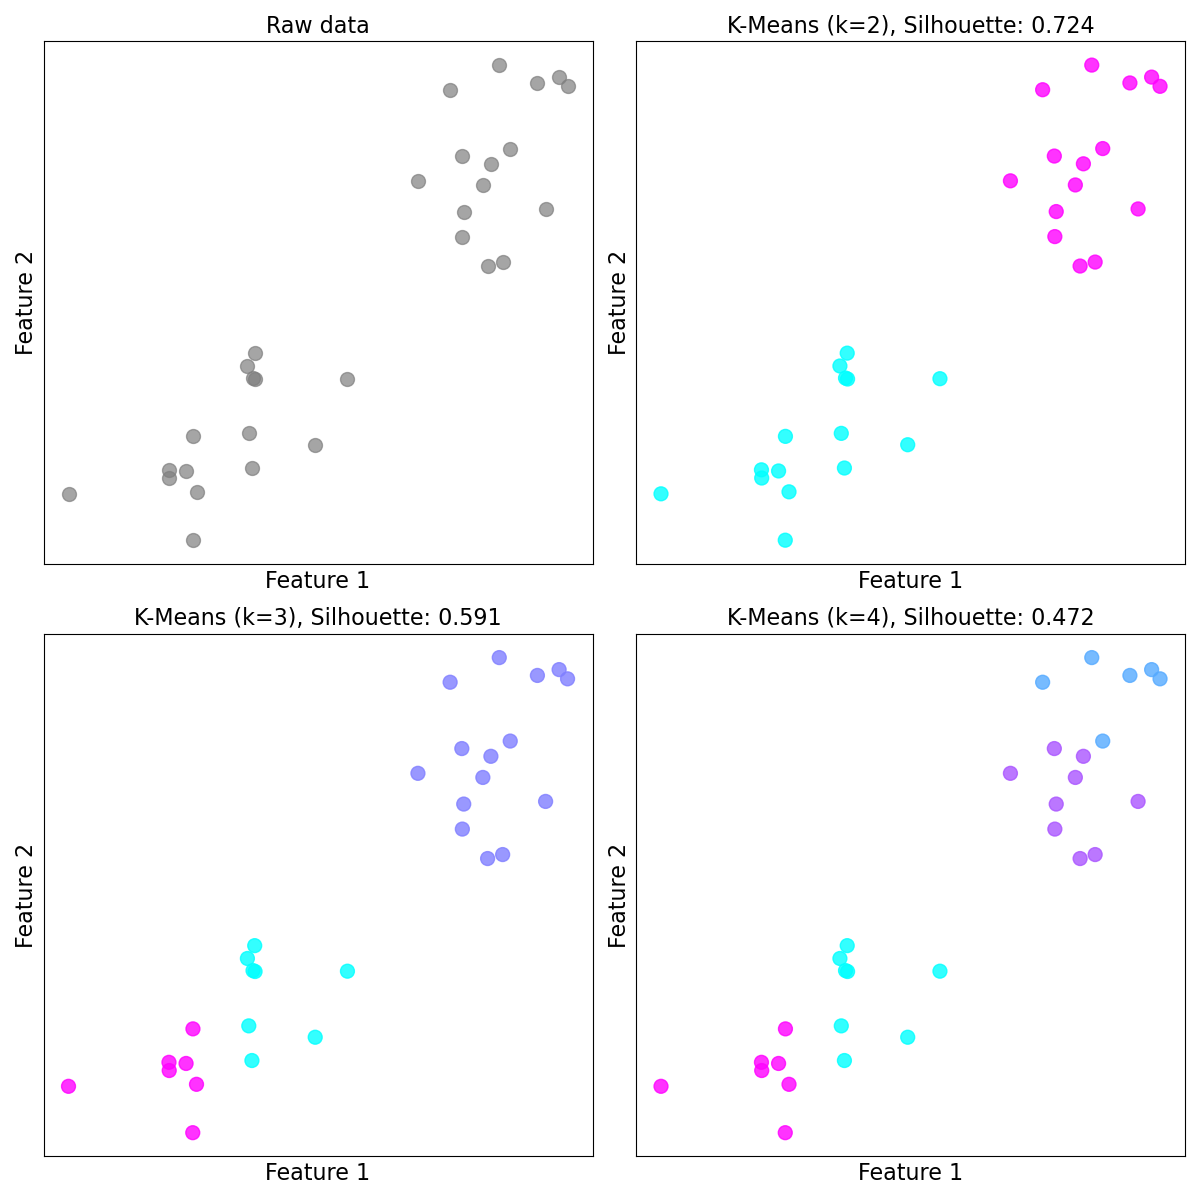

In [2]:
from IPython.display import Image, display
display(Image("../images/clustering/clustering-raw-data.png", width=1240))

<div class='alert alert-warning'>

:::{callout}

It should be emphasized that interpretation of clustering results is subjective
- while an algorithm can identify groups, it is up to us to determine whether those groups are meaningful or merely artifacts of algorithm
- Clustering outcomes are also highly sensitive to choice of algorithm and distance metric
	- K-Means tends to find spherical clusters
	- DBSCAN can detect arbitrarily shaped clusters and identify outliers
		- this may lead to very different conclusions using same dataset
- **there is no fixed set of rules to determine similarity between data points, which is why different clustering algorithms use different rules**.
:::
</div>

## 2. Load Dataset & Data Preparation

Following the procedures used in previous episodes, we apply the same preprocessing steps to the Penguins dataset, including handling missing values and detecting outliers. For the clustering task, categorical features are not required, so encoding them is unnecessary.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins_clustering = penguins.dropna()
penguins_clustering.duplicated().value_counts()

The data processing is straightforward for the clustering task: we simply extract the numerical variables and apply standardization.

In [ ]:
X = penguins_clustering[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. K-Means Clustering

### 3.1 What is K-Means

**K-Means**, a centroid-based partitioning method, is a widely used unsupervised learning algorithm that divides data into *k* distinct, non-overlapping clusters.
- K-Means operates on a simple yet powerful principle
	- each cluster is represented by its centroid, which is mean position of all points within cluster
- algorithm begins by *randomly* (actually not so random, read more about [methods for generating initial centroid positions](../tutorials/7-clustering-generating-centroid-positions-for-KMeans-algorithm.ipynb)) initializing *k* centroids in feature space and then iteratively refines their positions through a two-step **expectation**-**maximization** process.
	- in expectation step, each data point is assigned to its nearest centroid based on Euclidean distance, forming preliminary clusters
	- in maximization step, centroids are recalculated as mean of all points assigned to each cluster
- this process repeats until convergence, typically when centroid positions stabilize or cluster assignments no longer change significantly
    - or a user-defined tolerance or a maximum number of iterations is reached



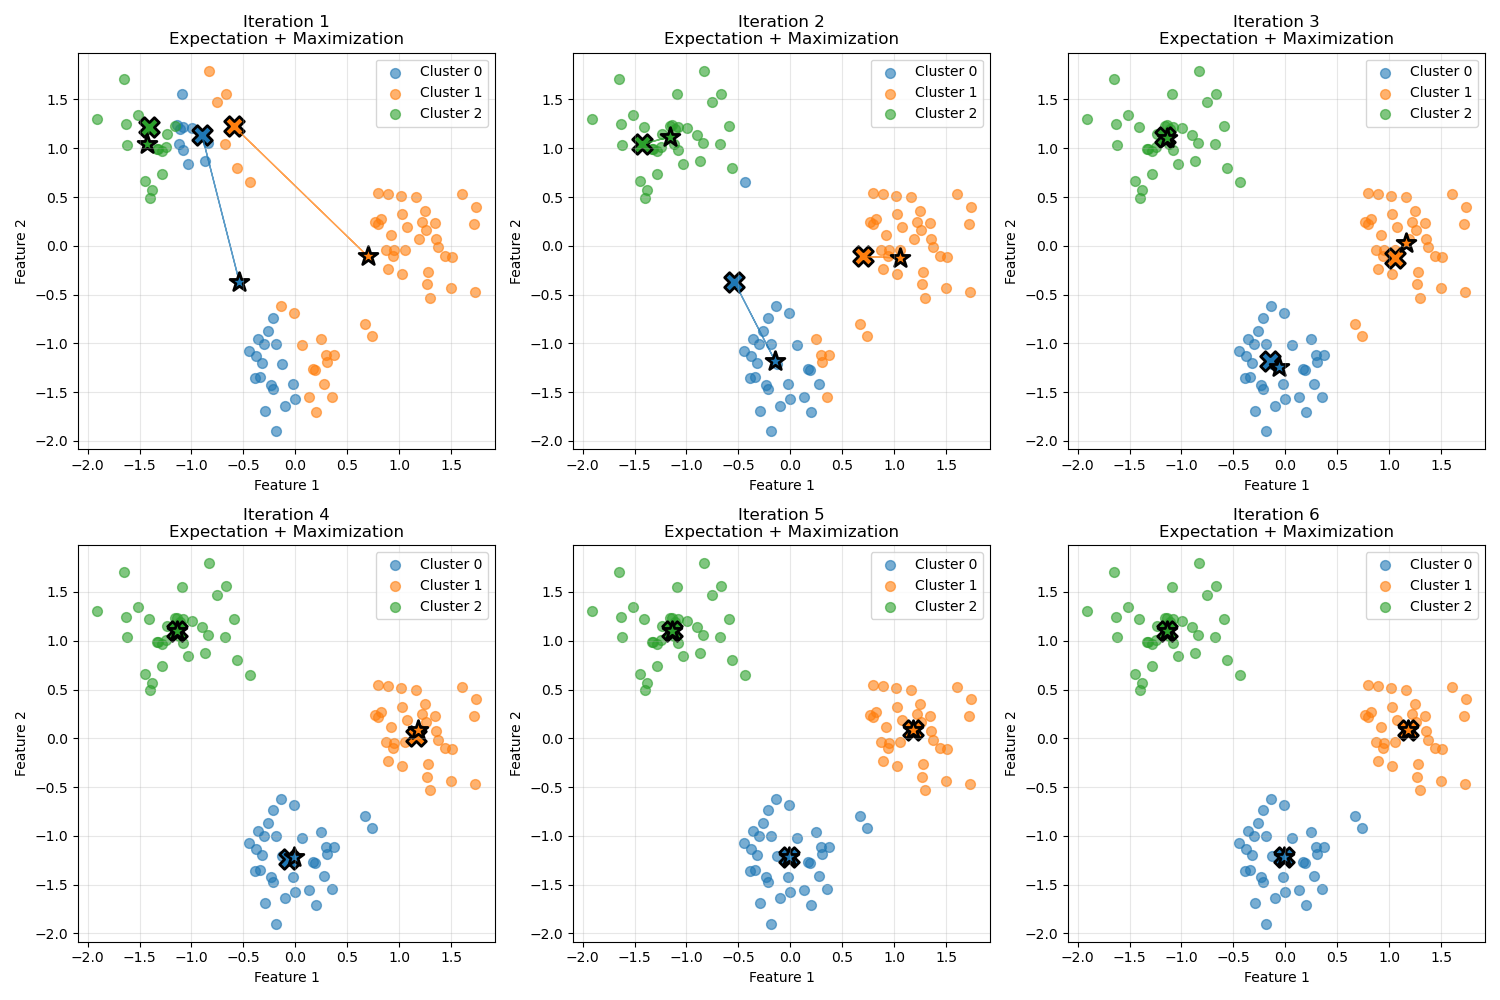

In [5]:
display(Image("../images/clustering/kmeans-description-expectation-maximization.png", width=1240))

Below we build a `kmeans` model using `KMeans` class from `sklearn.cluster` with specified parameters
- `n_clusters=k`, number of clusters to find from dataset
- `n_init=10`, number of times KMeans runs with different centroid seeds (default 10 or more), choose final model with lowest within-cluster sum of squared errors
    - default algorithm is `init='kmeans++`, which leads to better and more consistent results than other algorithms
    - `init='random'`, randomly initializing *k* centroids in feature space before iteratively refining their positions
	- actually not so random, check a tutorial [here](../tutorials/7-clustering-generating-centroid-positions-for-KMeans-algorithm.ipynb)
    - `random_state`, ensures reproducibility
- `max_iter` specifies maximum number of iterations for each single run
	- note that k-means implementation in scikit-learn stops early if it converges before maximum number of iterations is reached
	- however, it is possible that k-means does not reach convergence for a particular run, which can be problematic (computationally expensive) if we choose relatively large values for `max_iter`
    - one way to deal with convergence problems is to choose larger values for `tol`, which is a parameter that controls tolerance with regard to changes in within-cluster sum-squared-error to declare convergence
- by fitting constructed `kmeans` model, we can obtain cluster ID to which each point belongs

In [2]:
from sklearn.cluster import KMeans

k = 3
kmeans_model = KMeans(n_clusters=k, n_init=10, random_state=123) # init='random', max_iter=300, tol=1e-04
kmeans_pred_labels = kmeans_model.fit_predict(X_scaled)

Evaluating clustering efficiency can be tricky because, unlike supervised learning, we don’t always have "true labels"
- depending on whether we have ground truth or not, there are two main evaluation approaches:
	- if we don't know actual labels, we can measure how well each data point fits within its assigned cluster compared to other clusters, such as **Silhouette Score**
	- if we know actual labels (*e.g.*, penguin species), we can measure how well clustering recovers them, such as **Adjusted Rand Index** (ARI)
- <mark>**Silhouette Score**</mark> ranges between -1 to +1
    - a score of +1 indicates that samples in dataset are well-matched to their own cluster and clearly separated from other clusters
    - a score of 0 suggests that samples lie on boundary between clusters
    - a score of -1 implies that samples may have been incorrectly assigned to clusters
    - **Note**: this score does not work very well when using densitybased algorithms such as DBSCAN.
- <mark>**Higher ARI values**</mark> indicate that clustering results align closely with true groupings
    - an ARI of 1.0 represents perfect agreement
    - an ARI of 0.0 corresponds to random clustering
    - a negative ARI values suggest clustering performance worse than random chance
- <mark>**Calinski–Harabasz Index**</mark>

In [3]:
# add cluster labels to dataframe
penguins_kmeans = penguins.dropna().copy()
penguins_kmeans['kmeans_cluster'] = kmeans_pred_labels

# evaluate clustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
penguins_kmeans_sil_scores = silhouette_score(X_scaled, kmeans_pred_labels)
penguins_kmeans_ari_scores = adjusted_rand_score(penguins_kmeans['species'], kmeans_pred_labels)
print(f"Silhouette Score: {penguins_kmeans_sil_scores:.3f}")
print(f"Adjusted Rand Index (vs true species): {penguins_kmeans_ari_scores:.3f}")

Silhouette Score: 0.446
Adjusted Rand Index (vs true species): 0.799


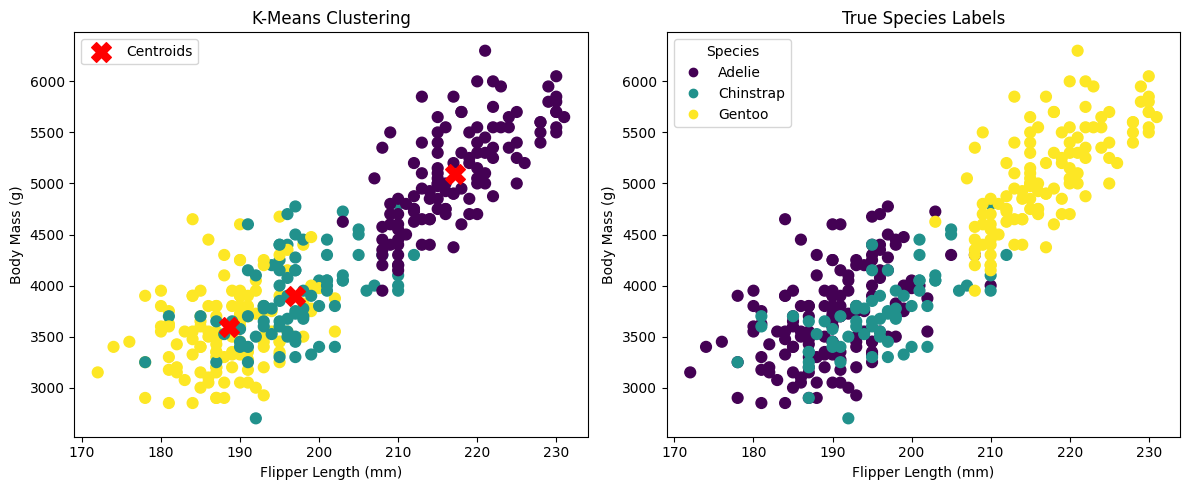

In [4]:
# visualize distributions of penguins by comparing their true labels with clusters determined by kmeans model

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot KMeans clusters
axes[0].scatter(
    penguins_kmeans['flipper_length_mm'],
    penguins_kmeans['body_mass_g'],
    c = penguins_kmeans['kmeans_cluster'],
    cmap='viridis',
    s=60
)
axes[0].scatter(
    kmeans_model.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],  # inverse scaling
    kmeans_model.cluster_centers_[:, 3] * scaler.scale_[3] + scaler.mean_[3],
    c='red', marker='X', s=200, label='Centroids'
)
axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Flipper Length (mm)")
axes[0].set_ylabel("Body Mass (g)")
axes[0].legend()

# plot true species for comparison
species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
colors = [species_map[s] for s in penguins_kmeans['species']]
scatter = axes[1].scatter(
    penguins_kmeans['flipper_length_mm'],
    penguins_kmeans['body_mass_g'],
    c=colors,
    cmap='viridis',
    s=60
)
axes[1].set_title("True Species Labels")
axes[1].set_xlabel("Flipper Length (mm)")
axes[1].set_ylabel("Body Mass (g)")

handles, labels = scatter.legend_elements()
axes[1].legend(handles, species_map.keys(), title="Species")

plt.tight_layout()
plt.show()

We have 333 penguins, and from plots above it is difficult to determine how many penguins belong to each cluster and what their species are
- this can be clarified by examining distribution of penguin species across clusters and computing a cross-tabulation of two categorical variables using `.crosstab()` method in Pandas


Species distribution in clusters:
species         Adelie  Chinstrap  Gentoo
kmeans_cluster                           
0                    0          0     119
1                   22         63       0
2                  124          5       0


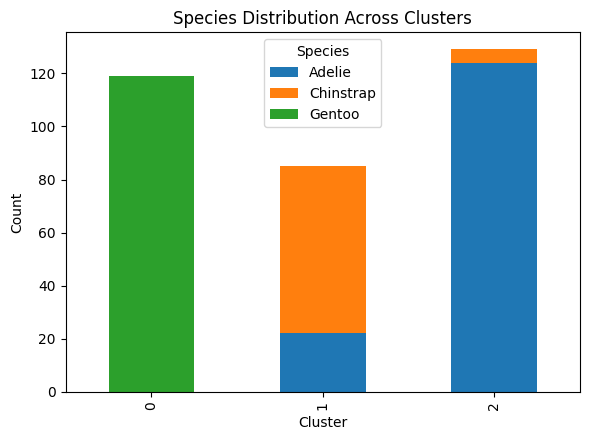

In [5]:
print("\nSpecies distribution in clusters:")
cross_tab = pd.crosstab(penguins_kmeans['kmeans_cluster'], penguins_kmeans['species'])
print(cross_tab)
    
# plot species distribution in clusters
cross_tab.plot(kind='bar', stacked=True, figsize=(6, 4.5))
plt.title('Species Distribution Across Clusters')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Species')
plt.tight_layout()
plt.show()

### 3.2 Determining optimal cluster number

At beginning of this section, we set `n_clusters = 3`, because we already knew that Penguins dataset contains three species
- however, in many real-world applications, true number of groups or clusters is not known in advance
- in such cases, it becomes essential to estimate appropriate number of clusters before performing actual clustering task
- to address this, we employ two widely-used heuristic methods, **Elbow method** and **Silhouette score analysis** to determine optimal cluster number `k`
- **Elbow method** quantifies quality of clustering using **Within-Cluster Sum of Squares** (WCSS), which measures how tightly data points in each cluster are grouped around their centroid
	- intuitively, we want clusters that are tight and cohesive, which corresponds to a low WCSS
	- as we increase number of clusters `k`, WCSS will always decrease because clusters become smaller and tighter
	- beyond a certain point, improvement of `k` becomes marginal contribution to WCSS
	- by plotting WCSS against number of clusters, we look for **elbow point** in curve, which represents a good balance between model complexity and cluster compactness
    - regarding accuracy of this indicator, elbow method is, as you can see, a heuristic and not mathematically determined, but can be of use if you want to make a quick estimate of right number of clusters, especially when curve changes very abruptly at some point
- **Silhouette score analysis** evaluates quality of clustering by measuring how similar each data point is to its own cluster compared to other clusters
	- for a single data point, silhouette coefficient compares average distance to points in its own cluster (cohesion) to average distance to points in nearest neighboring cluster (separation)


We rerun the computation using the K-Means algorithm across a range of cluster values. For each tested number of clusters, we compute both the WCSS and the Silhouette Score. By plotting these metrics against the number of clusters *k*, we can visually assess the trade-offs and identify the most suitable cluster count. The code example and corresponding output are shown below.

In [6]:
# determining optimal number of clusters

max_clusters = 15
wcss = []  # within-Cluster Sum of Square
silhouette_scores = []

for i in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    # calculate silhouette score
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    
    print(f"Clusters: {i}, WCSS: {kmeans.inertia_:.2f}, Silhouette: {silhouette_avg:.3f}")

optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Suggested optimal number of clusters: {optimal_clusters}")

Clusters: 2, WCSS: 552.67, Silhouette: 0.531
Clusters: 3, WCSS: 370.77, Silhouette: 0.446
Clusters: 4, WCSS: 305.43, Silhouette: 0.419
Clusters: 5, WCSS: 228.57, Silhouette: 0.374
Clusters: 6, WCSS: 211.22, Silhouette: 0.338
Clusters: 7, WCSS: 183.32, Silhouette: 0.328
Clusters: 8, WCSS: 167.30, Silhouette: 0.299
Clusters: 9, WCSS: 163.18, Silhouette: 0.260
Clusters: 10, WCSS: 150.37, Silhouette: 0.274
Clusters: 11, WCSS: 137.59, Silhouette: 0.279
Clusters: 12, WCSS: 140.77, Silhouette: 0.236
Clusters: 13, WCSS: 133.34, Silhouette: 0.219
Clusters: 14, WCSS: 133.33, Silhouette: 0.214
Clusters: 15, WCSS: 124.73, Silhouette: 0.237
Suggested optimal number of clusters: 2


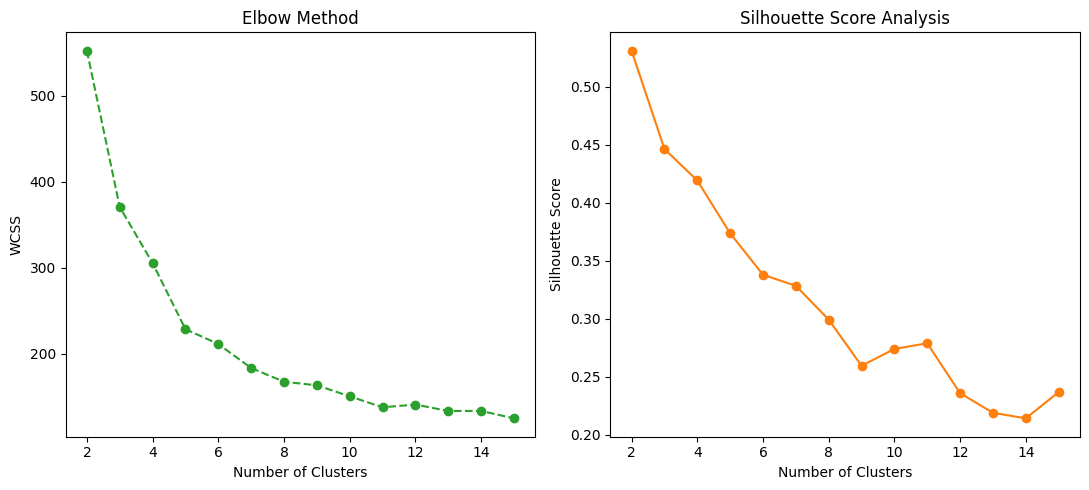

In [7]:
# plot elbow method

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, max_clusters + 1), wcss, marker='o', linestyle='--', color="tab:green")
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o', color='tab:orange')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')

plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

:::{callout} Why does K-Means suggest grouping the penguins into 2 clusters?
- K-Means algorithm suggest to group penguins into 2 clusters (instead of 3!) in Penguins dataset, this happens for several reasons
- feature overlap between species
	- some penguin species, like Adelie and Chinstrap, have very similar measurements for features
	- k-means uses Euclidean distance, so if two species’ points are close in feature space, algorithm may group them into a single cluster
- K-Means assumes spherical clusters
	- k-means works best when clusters are roughly spherical and equally sized
	- if clusters have different shapes, densities, or overlap, k-means may merge two clusters to minimize WCSS, resulting in fewer clusters than actual number of species
- Elbow or Silhouette methods suggest to have 2 clusters
	- when using Elbow Bethod, WCSS curve may show a clear "elbow" at k=2, indicating that adding a 3d cluster doesn’t significantly reduce WCSS
	- similarly, average Silhouette Score might be highest for k=2, because splitting overlapping species into separate clusters reduces cohesion.
:::
</div>

Figure below illustrates how penguins data points are grouped into 2, 3, and 4 clusters.
- This visualization demonstrates how clustering algorithm organizes data at different levels of granularity.

In [8]:
# comparison of k = 2, 3, and 4

penguins_cluster_k234 = penguins_kmeans.copy()

# apply K-Means with k=2
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = kmeans2.fit_predict(X_scaled)
penguins_cluster_k234['cluster_k2'] = labels2

# apply K-Means with k=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = kmeans3.fit_predict(X_scaled)
penguins_cluster_k234['cluster_k3'] = labels3

# apply K-Means with k=4
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = kmeans4.fit_predict(X_scaled)
penguins_cluster_k234['cluster_k4'] = labels4

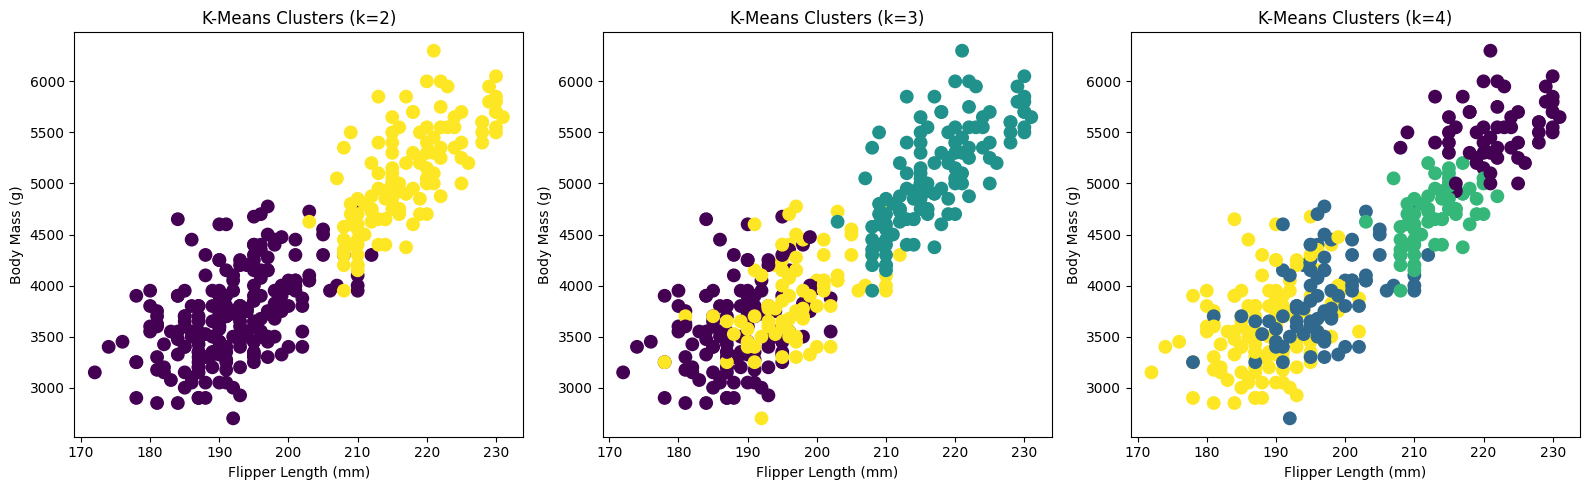

In [9]:
# plot distributions of data points in clusters

fig, axes = plt.subplots(1, 3, figsize=(16,5))

# k=2 clusters
axes[0].scatter(penguins_cluster_k234['flipper_length_mm'], penguins_cluster_k234['body_mass_g'], 
                c=penguins_cluster_k234['cluster_k2'], cmap='viridis', s=80)
axes[0].set_title('K-Means Clusters (k=2)')
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Body Mass (g)')

# k=3 clusters
axes[1].scatter(penguins_cluster_k234['flipper_length_mm'], penguins_cluster_k234['body_mass_g'], 
                c=penguins_cluster_k234['cluster_k3'], cmap='viridis', s=80)
axes[1].set_title('K-Means Clusters (k=3)')
axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Body Mass (g)')

# k=4 clusters
axes[2].scatter(penguins_cluster_k234['flipper_length_mm'], penguins_cluster_k234['body_mass_g'], 
                c=penguins_cluster_k234['cluster_k4'], cmap='viridis', s=80)
axes[2].set_title('K-Means Clusters (k=4)')
axes[2].set_xlabel('Flipper Length (mm)')
axes[2].set_ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

In [10]:
# print cluster counts

print("Cluster counts for k=2:\n", penguins_cluster_k234['cluster_k2'].value_counts())
print("Cluster counts for k=3:\n", penguins_cluster_k234['cluster_k3'].value_counts())
print("Cluster counts for k=4:\n", penguins_cluster_k234['cluster_k4'].value_counts())

Cluster counts for k=2:
 cluster_k2
0    214
1    119
Name: count, dtype: int64
Cluster counts for k=3:
 cluster_k3
0    129
1    119
2     85
Name: count, dtype: int64
Cluster counts for k=4:
 cluster_k4
3    129
1     85
2     62
0     57
Name: count, dtype: int64


## 4. Hierarchical Clustering

### 4.1 What is Hierarchical clustering

**Hierarchical clustering** is an unsupervised learning method that builds a hierarchy of clusters by either divisive (top-down) or agglomerative (bottom-up) strategies
- in agglomerative approach, each data point starts as its own cluster, and algorithm iteratively merges closest clusters based on a distance metric
- this continues until all points are merged into a single cluster
- result can be visualized as a **dendrogram**, a tree-like diagram showing nested structure of clusters at different levels of granularity.

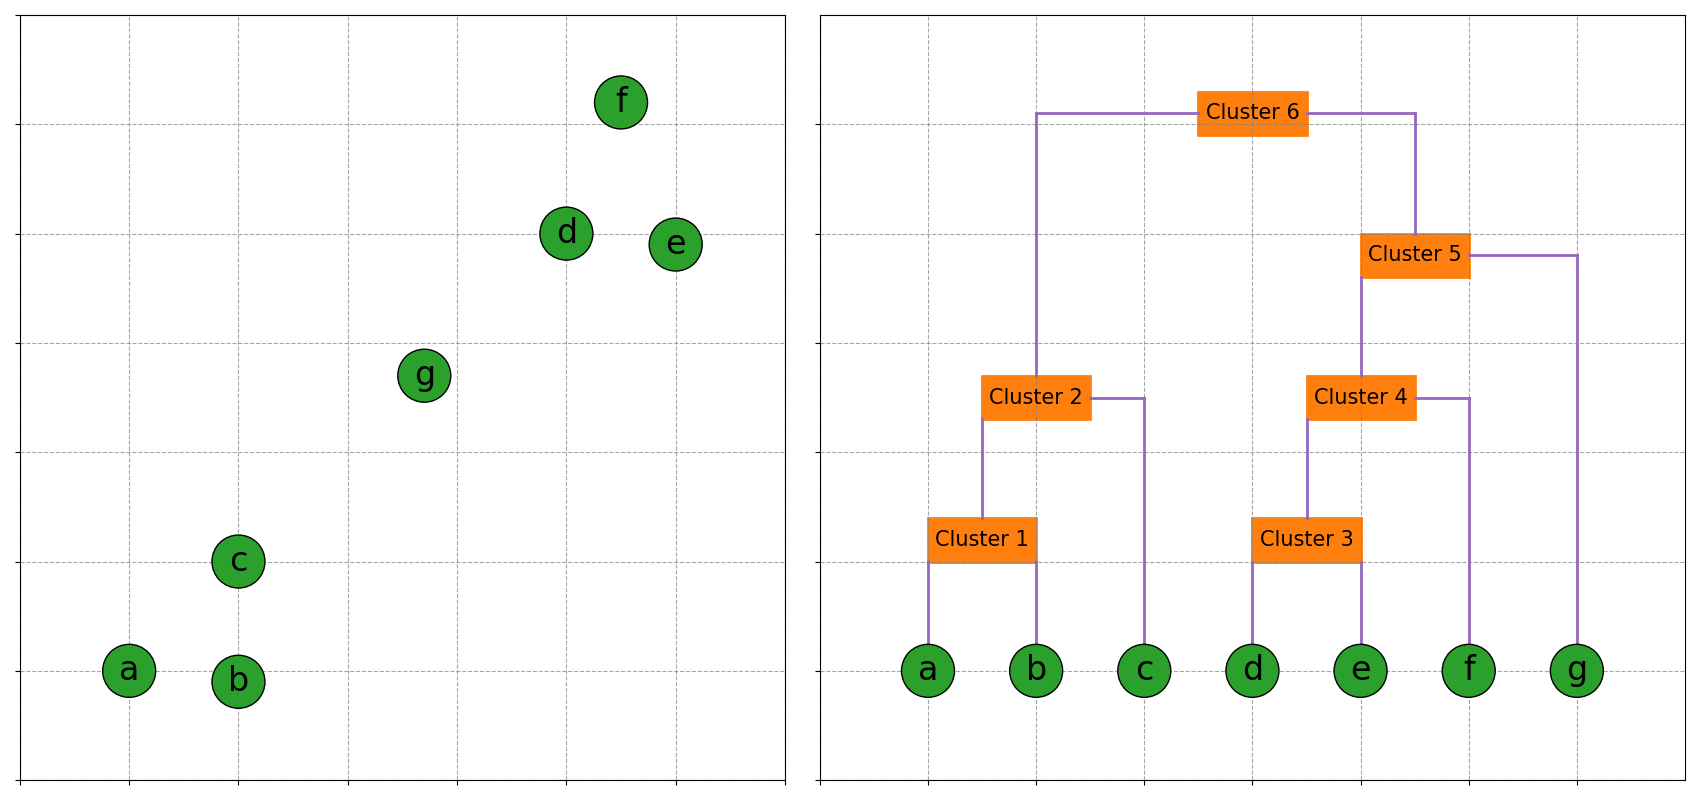

In [10]:
display(Image("../images/clustering/hierarchical-clustering-example.png", width=1240))

<div class='alert alert-info'>

:::{callout} Hierarchical Clustering vs. Decision Tree
- hierarchical clustering is conceptually similar to a decision tree in some ways, but it is not same as a decision tree or random forest
- similarity is that both build a tree-like structure
- key differences
	- purpose of tree
		- in Hierarchical clustering, tree (dendrogram) represents nested clusters and shows order in which points/clusters are merged or split
		- in Decision Tree, tree represents decision rules to predict a target variable
	- supervised *vs.* unsupervised algorithms
	- with and without ensemble concept
		- random forest is an ensemble of decision trees and focuses on improving prediction accuracy and reducing overfitting
		- hierarchical clustering has no ensemble concept or predictive objective; it is purely descriptive
- in short, **hierarchical clustering is structurally similar to a tree (like a dendrogram)**, but **it is unsupervised and descriptive, unlike Decision Trees or Random Forests, which are supervised and predictive**.
:::
</div>

For clustering task, we can use SciPy and Scikit-Learn packages
- in SciPy, hierarchical clustering involves two steps
- **computing linkage matrix**
	- `linkage()` computes full hierarchical clustering tree (linkage matrix), storing all merges, distances, and cluster sizes
- **extracting clusters from it**
	- `fcluster()` cuts dendrogram at a specified threshold to produce a flat clustering, here forming 3 clusters (``t=3``, criterion='maxclust')

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# compute linkage matrix
linked = linkage(X_scaled, method='ward')

# assign 3 clusters based on dendrogram cut
labels_scipy = fcluster(linked, t=3, criterion='maxclust')

penguins_clustering = penguins.dropna().copy()
penguins_clustering['hierC_scipy'] = labels_scipy

In [12]:
# evaluate clustering
sil_score_hier_scipy = silhouette_score(X_scaled, labels_scipy)
ari_score_hier_scipy = adjusted_rand_score(penguins_clustering['species'], labels_scipy)
print(f"Silhouette Score: {sil_score_hier_scipy:.3f}")
print(f"Adjusted Rand Index (vs true species): {ari_score_hier_scipy:.3f}")

# penguins_clustering['hierC_scipy'] = labels_scipy
penguins_clustering

Silhouette Score: 0.452
Adjusted Rand Index (vs true species): 0.913


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,hierC_scipy
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,1
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1


Next we plot the dendrogram to visualize clustering structure.

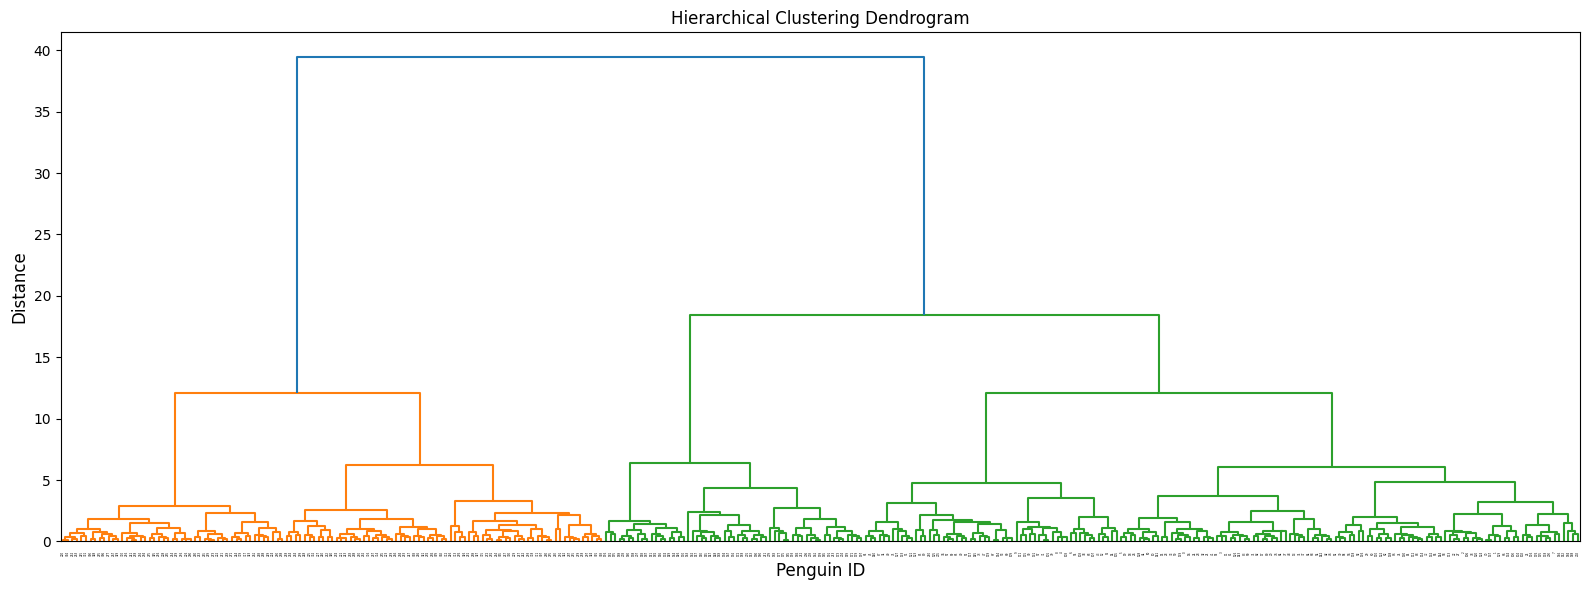

In [13]:
# plot dendrogram to visualize clustering structure

plt.figure(figsize=(16, 6))
dendrogram(
    linked,
    # labels=penguins_cluster['species'].values,  # for leaf labels
    leaf_rotation=90,
    leaf_font_size=2
)
plt.title("Hierarchical Clustering Dendrogram", fontsize=12)
plt.xlabel("Penguin ID", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

Below we employ `AgglomerativeClustering` to construct clustering model with hyperparameters
- `linkage` determines how distance between clusters is calculated, there are several options for this parameters
	- `ward`,  minimizes variance of merged clusters (only works with Euclidean distance)
	- `complete`, maximum distance between points in clusters
	- `average`, average distance between points in clusters
	- `single`, minimum distance between points in clusters
- parameter ``metric`` is distance metric used to compute distance between points
	- `euclidean` is standard straight-line distance in feature space
	- there are other options like ``manhattan``, ``cosine``, *etc.*

In [14]:
# agglomerative clustering from scikit-learn (choose number of clusters, e.g., 3)

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_aggl = hc.fit_predict(X_scaled)

# evaluate clustering
sil_score_hier_aggl = silhouette_score(X_scaled, labels_aggl)
ari_score_hier_aggl = adjusted_rand_score(penguins_clustering['species'], labels_aggl)
print(f"Silhouette Score: {sil_score_hier_aggl:.3f}")
print(f"Adjusted Rand Index (vs true species): {ari_score_hier_aggl:.3f}")

# add cluster labels to dataframe
penguins_clustering['hierC_aggl'] = labels_aggl
penguins_clustering

Silhouette Score: 0.452
Adjusted Rand Index (vs true species): 0.913


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,hierC_scipy,hierC_aggl
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3,1
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3,1
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3,1
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3,1
...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,1,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1,0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1,0


We can examine the number of penguins in each species within the clusters determined by the two models, and visualize their distributions using a confusion matrix.

In [15]:
# check distribution of species in clusters

print("\nSpecies distribution in hierarchical clusters:\n")

print(pd.crosstab(penguins_clustering['species'], penguins_clustering['hierC_scipy']), '\n')
print(pd.crosstab(penguins_clustering['species'], penguins_clustering['hierC_aggl']))


Species distribution in hierarchical clusters:

hierC_scipy    1   2    3
species                  
Adelie         0   0  146
Chinstrap      0  57   11
Gentoo       119   0    0 

hierC_aggl    0    1   2
species                 
Adelie        0  146   0
Chinstrap     0   11  57
Gentoo      119    0   0


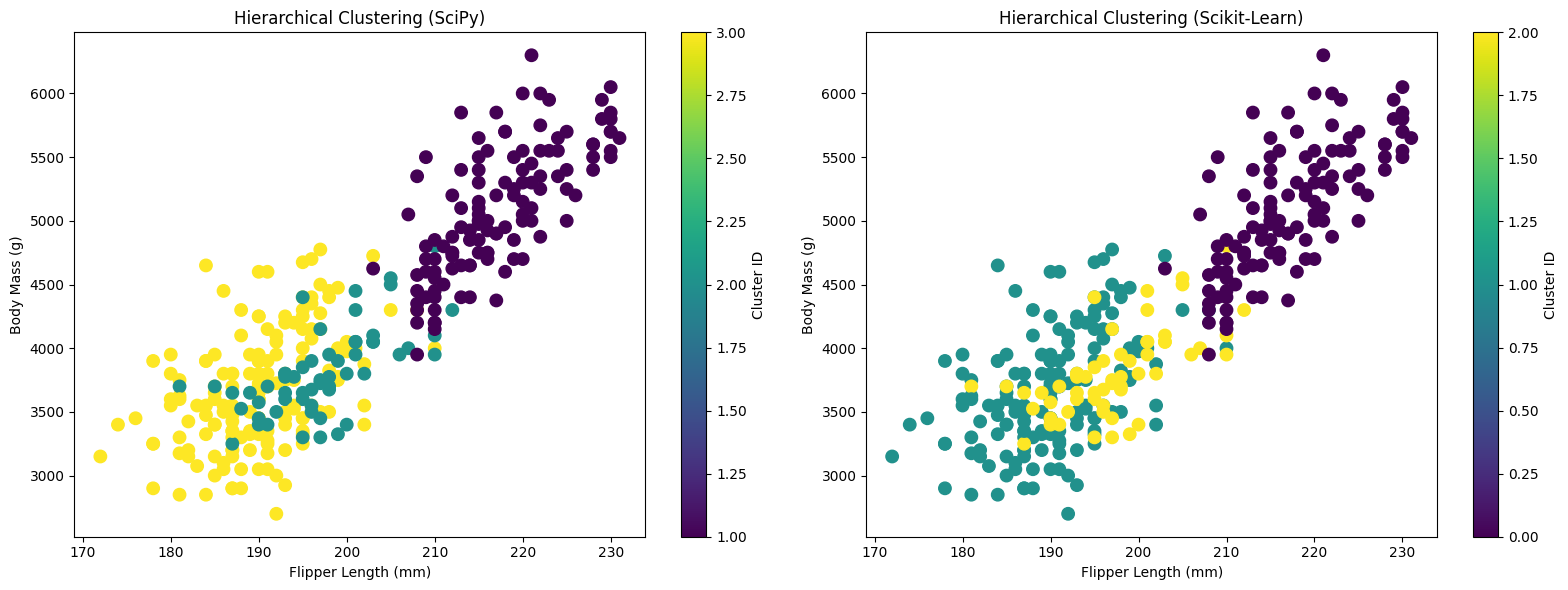

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# clusters determined using SciPy
scatter1 = axes[0].scatter(
    penguins_clustering['flipper_length_mm'],
    penguins_clustering['body_mass_g'],
    c=labels_scipy,
    cmap='viridis',
    s=80
)
axes[0].set_xlabel("Flipper Length (mm)")
axes[0].set_ylabel("Body Mass (g)")
axes[0].set_title("Hierarchical Clustering (SciPy)")
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label("Cluster ID")

# clusters determined using Scikit-Learn
scatter2 = axes[1].scatter(
    penguins_clustering['flipper_length_mm'],
    penguins_clustering['body_mass_g'],
    c=labels_aggl,
    cmap='viridis',
    s=80
)
axes[1].set_xlabel("Flipper Length (mm)")
axes[1].set_ylabel("Body Mass (g)")
axes[1].set_title("Hierarchical Clustering (Scikit-Learn)")
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label("Cluster ID")

plt.tight_layout()
plt.show()

In [17]:
# calculation of confusion matrix

# clusters determined using Scikit-Learn
# map clusters to species (majority vote)
cluster_mapping = penguins_clustering.groupby('hierC_aggl')['species'].agg(lambda x: x.value_counts().idxmax()).to_dict()
predicted_species = penguins_clustering['hierC_aggl'].map(cluster_mapping)
# compute confusion matrix as a DataFrame
cm_aggl = pd.crosstab(penguins_clustering['species'], predicted_species)

# clusters determined using SciPy
cluster_mapping = penguins_clustering.groupby('hierC_scipy')['species'].agg(lambda x: x.value_counts().idxmax()).to_dict()
predicted_species = penguins_clustering['hierC_scipy'].map(cluster_mapping)
cm_scipy = pd.crosstab(penguins_clustering['species'], predicted_species)

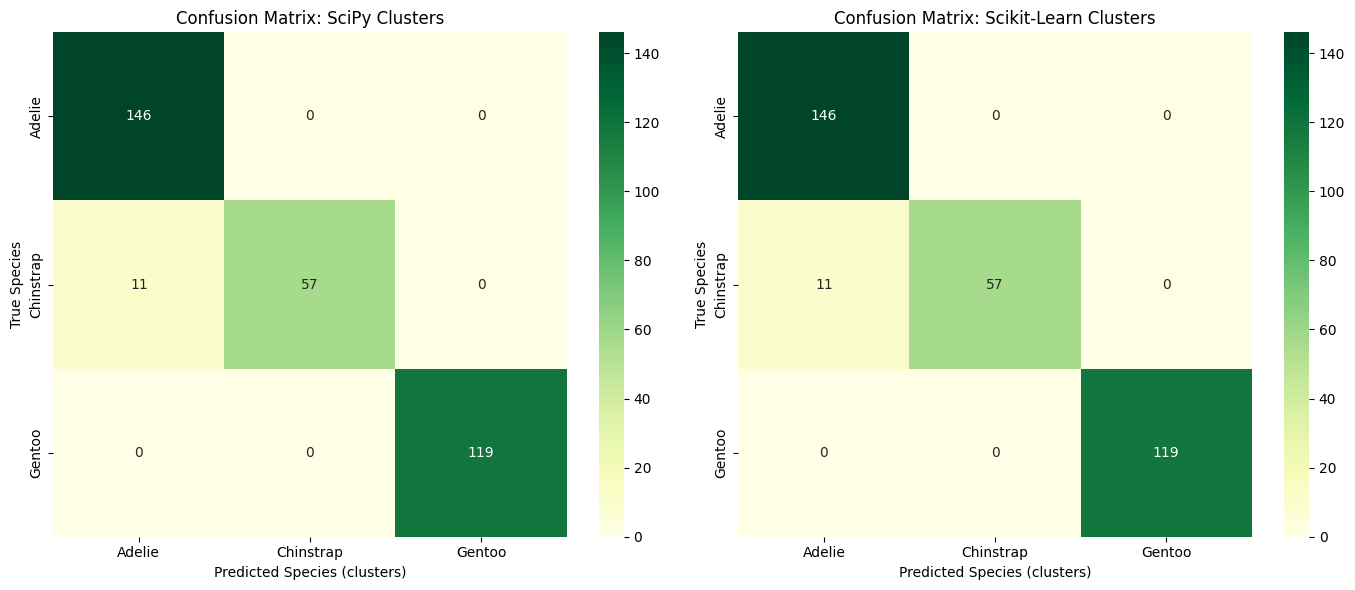

In [18]:
# visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# SciPy clusters
sns.heatmap(cm_scipy, annot=True, fmt="d", cmap="YlGn", ax=axes[0])
axes[0].set_title("Confusion Matrix: SciPy Clusters")
axes[0].set_xlabel("Predicted Species (clusters)")
axes[0].set_ylabel("True Species")

# Scikit-Learn clusters
sns.heatmap(cm_aggl, annot=True, fmt="d", cmap="YlGn", ax=axes[1])
axes[1].set_title("Confusion Matrix: Scikit-Learn Clusters")
axes[1].set_xlabel("Predicted Species (clusters)")
axes[1].set_ylabel("True Species")

plt.tight_layout()
plt.show()

## 5. DBSCAN

### 5.1 What is DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups together points that are closely packed while marking points in low-density regions as outliers
- unlike K-Means, **DBSCAN does not require specifying number of clusters in advance**, making it particularly useful when number of natural clusters is unknown
- it is also capable of identifying clusters of arbitrary shapes, unlike centroid-based methods that assume roughly spherical clusters
	- this makes DBSCAN robust to clusters with irregular shapes or varying sizes
- below we build a model using `DBSCAN` class from `sklearn.cluster` with specified parameters
	- DBSCAN relies on two key parameters
	- `eps`, radius that defines neighborhood around a point
	- `min_samples`, minimum number of points required within a point’s `eps` neighborhood for it to be considered a core point
- DBSCAN classifies data points into three types
	- **core points**: points with at least ``min_samples`` neighbors within ``eps``
	- **border points**: points within ``eps`` of a core point but with fewer than ``min_samples`` neighbors themselves
	- **noise points** (outliers): points that are neither core nor border points

### 5.2 Train a DBSCAN model

In [19]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.55, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# evaluate clustering (only if at least 2 clusters found)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN found {n_clusters} clusters (and {sum(labels==-1)} noise points).")

if n_clusters > 1:
    sil_score_dbscan = silhouette_score(X_scaled, labels)  # FIXED
    ari_score_dbscan = adjusted_rand_score(penguins_clustering['species'], labels)
    print(f"Silhouette Score: {sil_score_dbscan:.3f}")
    print(f"Adjusted Rand Index (vs true species): {ari_score_dbscan:.3f}")

# add cluster labels to dataframe
penguins_clustering['dbscan_cluster'] = labels
penguins_clustering

DBSCAN found 3 clusters (and 44 noise points).
Silhouette Score: 0.378
Adjusted Rand Index (vs true species): 0.769


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,hierC_scipy,hierC_aggl,dbscan_cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3,1,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3,1,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3,1,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3,1,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3,1,0
...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,1,0,2
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1,0,2
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1,0,2
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1,0,2


Next, we visualize the distributions of penguins in each cluster, including any points identified as noise.

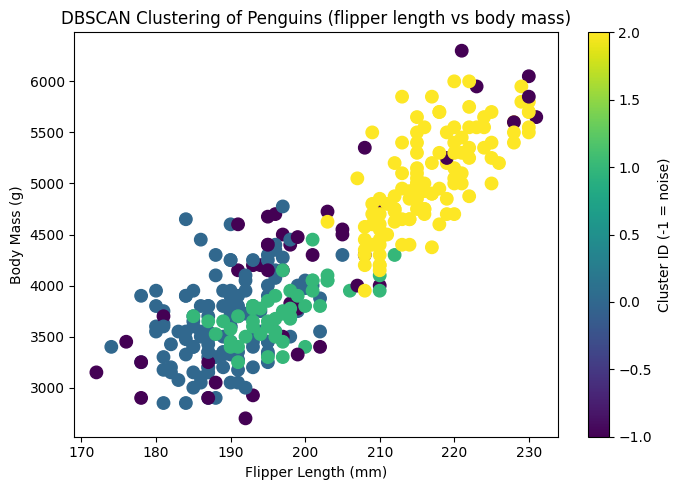

In [20]:
# visualization

plt.figure(figsize=(7,5))
scatter = plt.scatter(
    penguins_clustering['flipper_length_mm'], 
    penguins_clustering['body_mass_g'],
    c=labels, cmap='viridis', s=80
)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("DBSCAN Clustering of Penguins (flipper length vs body mass)")
plt.colorbar(scatter, label="Cluster ID (-1 = noise)")
plt.tight_layout()
plt.show()

We further examine the distribution of penguin species across clusters using the cross-tabulation (`.crosstab()`) method in Pandas.

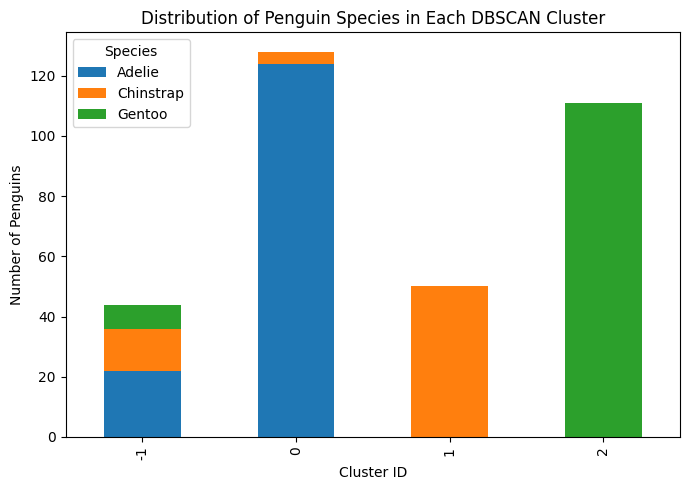

In [21]:
# cross-tabulation: species distribution in clusters

cross_tab = pd.crosstab(penguins_clustering['dbscan_cluster'], penguins_clustering['species'])
cross_tab.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title("Distribution of Penguin Species in Each DBSCAN Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Penguins")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

### 5.3 Determining optimal hyperparameters using grid search approach

Tuning performance of a **DBSCAN** model can be challenging, because unlike algorithms such as K-Means, we don’t directly specify number of clusters in advance
- clustering results depend strongly on two key parameters
	- `eps` (neighborhood radius) and `min_samples` (minimum points needed to form a dense region)
- two commonly used approaches are
	- **k-distance plot (for estimating `eps`)**
		- this method 1st computes distance to *k-th nearest neighbor* for each point, where `k = min_samples`
		- these distances are then sorted in ascending order and plotted
		- "elbow" or "knee" in curve typically indicates a good choice for `eps` parameter
	- **grid search over parameter space**
		- we select a range of candidate values for `eps` and `min_samples` and perform multiple DBSCAN runs using each combination
		- clustering quality will be evaluated using metrics such as Silhouette score (when at least two clusters are detected) or Adjusted Rand Index (ARI) when ground-truth labels are available
		- results are then visualized in a heatmap to reveal parameter regions that produce strong clustering performance

#### 5.3.1 Use a k-distance plot to determine `eps`

- compute distance to k-th nearest neighbor for each point (k = min_samples)
- sort these distances
- plot them and “elbow” point suggests a good `eps`

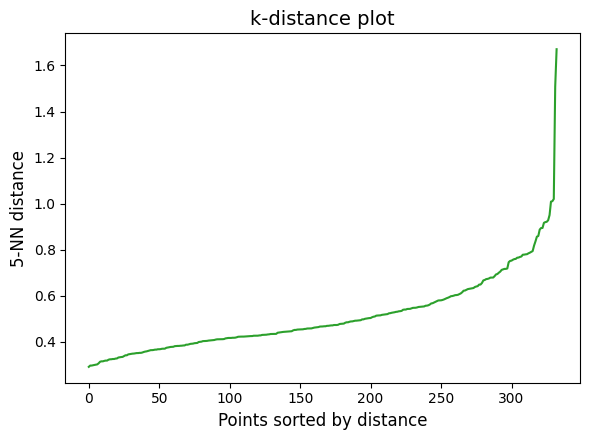

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# choose min_samples (say 5–10)
k = 5  
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# sort the k-th distances
fig = plt.subplots(figsize=(6, 4.5))
distances = np.sort(distances[:, k-1])
plt.plot(distances, "tab:green")
plt.ylabel(f"{k}-NN distance", fontsize=12)
plt.xlabel("Points sorted by distance", fontsize=12)
plt.title("k-distance plot", fontsize=14)
plt.tight_layout()
plt.show()

# from th plot, “elbow” point is approximated at eps ~ 0.8

#### 5.3.2 Use grid search approach

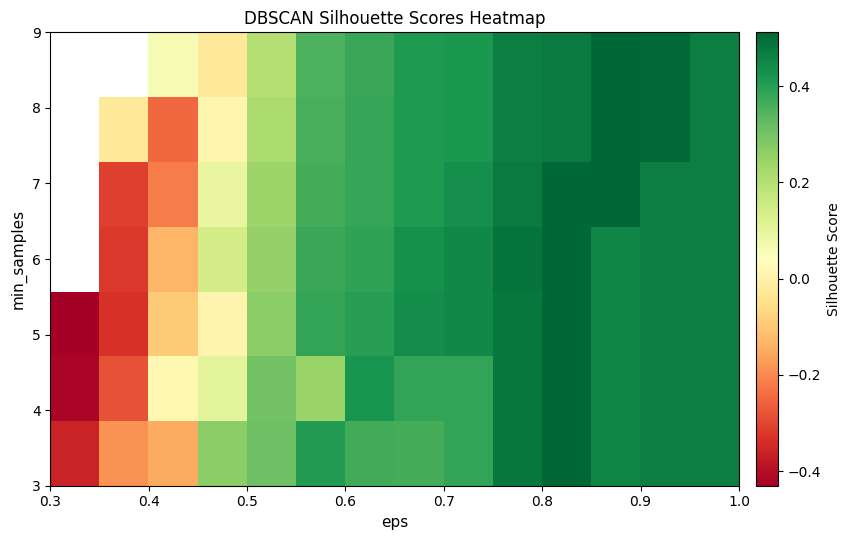

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.linspace(0.3, 1.0, 14)    # adjust range as needed
min_samples_values = range(3, 10)

sil_scores = np.full((len(min_samples_values), len(eps_values)), np.nan)

for i, min_samples in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:  # silhouette requires at least 2 clusters
            sil = silhouette_score(X_scaled, labels)
            sil_scores[i, j] = sil

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(
    sil_scores, cmap="RdYlGn", aspect="auto",
    extent=[eps_values[0], eps_values[-1], 
            min(min_samples_values), max(min_samples_values)],
    origin="lower"
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)  
cbar.set_label("Silhouette Score")

ax.set_xlabel("eps", fontsize=11)
ax.set_ylabel("min_samples", fontsize=11)
ax.set_title("DBSCAN Silhouette Scores Heatmap", fontsize=12)

plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

:::{callout}
In addition to DBSCAN, there are other density-based methods, and one of which is **Mean-Shift Algorithm**. Read more from [here](../tutorials/7-clustering-mean-shift-algorithm.ipynb).
:::
</div>

## 6. Gaussian Mixture Models

### 6.1 What is GMM model

After exploring centroid-based methods like K-Means, hierarchical clustering models, and density-based approaches such as DBSCAN, we now turn our attention to model-based clustering algorithms.
Unlike the previous methods that rely primarily on distance metrics or density thresholds, model-based clustering algorithm assumes that data come from a mixture of underlying **probability distributions**.
- each distribution corresponds to a cluster, and algorithm tries to estimate both parameters of distributions and clusters
- since model-based clustering assumes that a dataset is generated from a mixture of underlying probability distributions, a variety of algorithms have been developed to handle different types of distributions
- choice of model depends on nature of data
	- when dealing with continuous numerical features that approximately follow a bell-shaped distribution, **Gaussian Mixture Models** (GMMs) are most common choice
	- if data consists of count values, mixture models based on Poisson distributions can be used
	- for categorical data, methods like Latent Class Analysis (LCA), which treats clusters as latent categorical variables, are often applied
	- in more flexible Bayesian frameworks, Dirichlet Process Mixture Models allow number of clusters to be inferred directly from data, avoiding need to predefine it

GMM assumes that all data points are generated from a mixture of Gaussian distributions, each representing a cluster
- instead of assigning points strictly to one cluster (like K-Means), GMM assigns each point a probability of belonging to each cluster, making it a soft clustering method
- in following example, we construct GMM model with specified hyperparameters
	- `n_components=3` means number of Gaussian distributions (clusters) to fit
	- `covariance_type` controls form of covariance matrix for each Gaussian distribution
		- `full` means that each cluster has its own general covariance matrix (most flexible, allows ellipsoidal shapes)
		- other options like `tied`, `diag`, and `spherical` corresponding to clusters with different shapes

In [25]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

# build GMM model with 3 components (clusters)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)

# evaluate clustering performance
sil_score_gmm = silhouette_score(X_scaled, labels_gmm)
ari_score_gmm = adjusted_rand_score(penguins_clustering['species'], labels)
print(f"Silhouette Score: {sil_score_gmm:.3f}")
print(f"Adjusted Rand Index: {ari_score_gmm:.3f}")

# add cluster labels to dataframe
penguins_clustering['gmm_cluster'] = labels_gmm
penguins_clustering

Silhouette Score: 0.453
Adjusted Rand Index: 0.651


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,hierC_scipy,hierC_aggl,dbscan_cluster,gmm_cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3,1,0,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3,1,0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3,1,0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3,1,0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,1,0,2,1
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1,0,2,1
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1,0,2,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1,0,2,1


<div class='alert alert-info'>

Then we can 
- examine distribution of penguin species across clusters using cross-tabulation method
- visualize distribution of penguins within each cluster
- illustrate their distributions with a confusion matrix
</div>

In [26]:
# check species distribution in each cluster

print("\nSpecies distribution per GMM cluster:\n")
print(pd.crosstab(penguins_clustering['species'], penguins_clustering['gmm_cluster']))


Species distribution per GMM cluster:

gmm_cluster    0    1   2
species                  
Adelie       144    0   2
Chinstrap      3    0  65
Gentoo         0  119   0


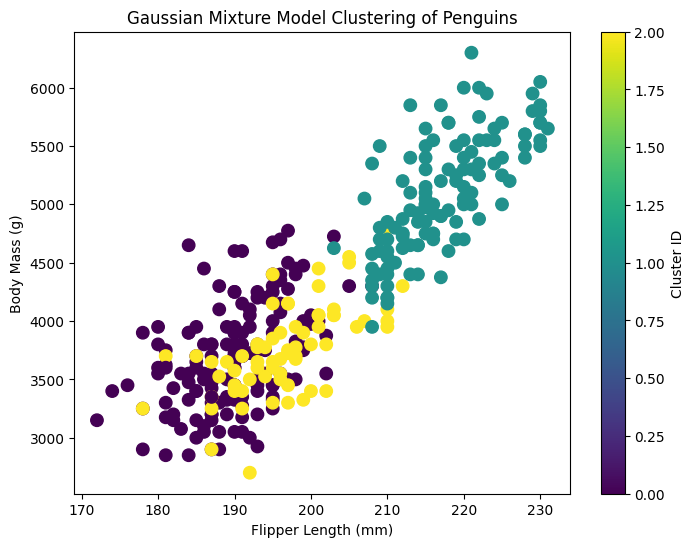

In [27]:
# visualization

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    penguins_clustering['flipper_length_mm'],
    penguins_clustering['body_mass_g'],
    c=labels_gmm, cmap='viridis', s=80
)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Gaussian Mixture Model Clustering of Penguins")
plt.colorbar(scatter, label="Cluster ID")
plt.show()

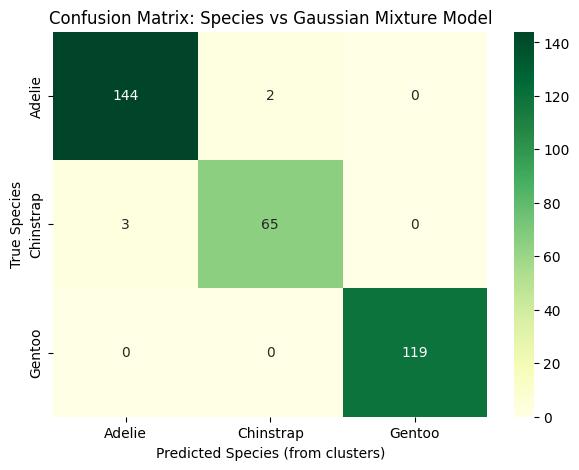

In [28]:
# map clusters to species (majority vote)
cluster_mapping = penguins_clustering.groupby('gmm_cluster')['species'].agg(lambda x: x.value_counts().idxmax()).to_dict()
predicted_species = penguins_clustering['gmm_cluster'].map(cluster_mapping)

# compute confusion matrix as a DataFrame
cm_gmm = pd.crosstab(penguins_clustering['species'], predicted_species)

# plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(cm_gmm, annot=True, fmt="d", cmap="YlGn")
plt.title("Confusion Matrix: Species vs Gaussian Mixture Model")
plt.xlabel("Predicted Species (from clusters)")
plt.ylabel("True Species")
plt.show()

### 6.2 <mark>**Shapes of clusters (KMeans vs GMM)**</mark>

Here, we specifically highlight the distributions penguins data points in clusters and the shape of clusters obtained from the K-Means and GMM models.

In [29]:
penguins_test = sns.load_dataset("penguins").dropna()
features_test = ['flipper_length_mm', 'body_mass_g']
X_test = penguins_test[features_test].values

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_test_scaled)
kmeans_centers = kmeans.cluster_centers_
kmeans_centers

array([[ 0.21508453,  0.17671622],
       [-0.83513472, -0.82727207],
       [ 1.36169807,  1.38607638]])

In [30]:
# GMM clustering

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_test_scaled)
gmm_labels = gmm.predict(X_test_scaled)
gmm_means = gmm.means_
gmm_covs = gmm.covariances_

In [31]:
# function to draw GMM ellipses

def plot_gmm_ellipses(gmm, ax):
    for i in range(gmm.n_components):
        mean = gmm.means_[i]
        cov = gmm.covariances_[i]
        v, w = np.linalg.eigh(cov)
        angle = np.arctan2(w[0][1], w[0][0])
        angle = np.degrees(angle)
        width, height = 2 * np.sqrt(v) * 1.5
        ell = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='red', fc='None', lw=2)
        ax.add_patch(ell)

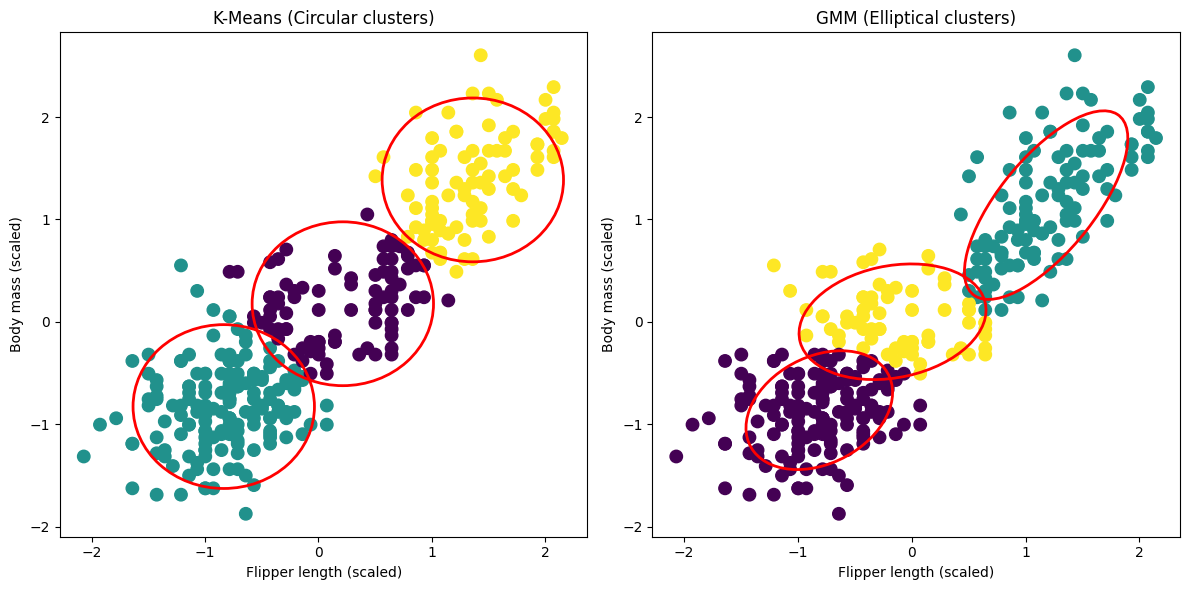

In [32]:
# plot shapes of clusters

from matplotlib.patches import Circle, Ellipse

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# left: K-Means with circles
axes[0].scatter(X_test_scaled[:,0], X_test_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=80)
for center in kmeans_centers:
    circle = Circle(center, radius=0.8, edgecolor='red', fc='None', lw=2)  # circular clusters
    axes[0].add_patch(circle)
axes[0].set_title("K-Means (Circular clusters)")
axes[0].set_xlabel("Flipper length (scaled)")
axes[0].set_ylabel("Body mass (scaled)")

# right: GMM with elliptical/larger shapes
axes[1].scatter(X_test_scaled[:,0], X_test_scaled[:,1], c=gmm_labels, cmap='viridis', s=80)
plot_gmm_ellipses(gmm, axes[1])
axes[1].set_title("GMM (Elliptical clusters)")
axes[1].set_xlabel("Flipper length (scaled)")
axes[1].set_ylabel("Body mass (scaled)")

plt.tight_layout()
plt.show()

## 7. Spectral Clustering

### 7.1 What is Spectra Clustering

**Spectral clustering** represents a fundamentally different approach: rather than relying purely on distances between points or density, **it leverages graph theory and eigenstructure of similarity matrices to uncover clusters**
- that is, main idea of this method is to represent dataset as a graph where each node is a data point and edges encode similarity between points (*e.g.*, using a Gaussian kernel)
- by computing eigenvectors of graph Laplacian, algorithm transforms original data into a lower-dimensional space where clusters become more distinguishable
- once in this space, standard clustering techniques, such as K-Means, are applied to assign cluster labels
- this method is especially powerful for datasets with complex, **non-convex** cluster shapes, where traditional algorithms like K-Means or Hierarchical clustering may fail to capture true underlying structure

In [33]:
from sklearn.cluster import SpectralClustering

# build model using Spectral Clustering (graph-based)
spectral = SpectralClustering(
    n_clusters=3,
    affinity='rbf',   # Gaussian kernel
    gamma=1.0,        # controls width of the Gaussian
    assign_labels='kmeans',
    random_state=42
)
labels = spectral.fit_predict(X_scaled)
penguins_clustering['spectral_cluster'] = labels

# evaluate clustering
sil_score_spectral = silhouette_score(X_scaled, labels)
ari_score_spectral = adjusted_rand_score(penguins_clustering['species'], labels)
print(f"Silhouette Score: {sil_score_spectral:.3f}")
print(f"Adjusted Rand Index (vs species): {ari_score_spectral:.3f}")

Silhouette Score: 0.460
Adjusted Rand Index (vs species): 0.820


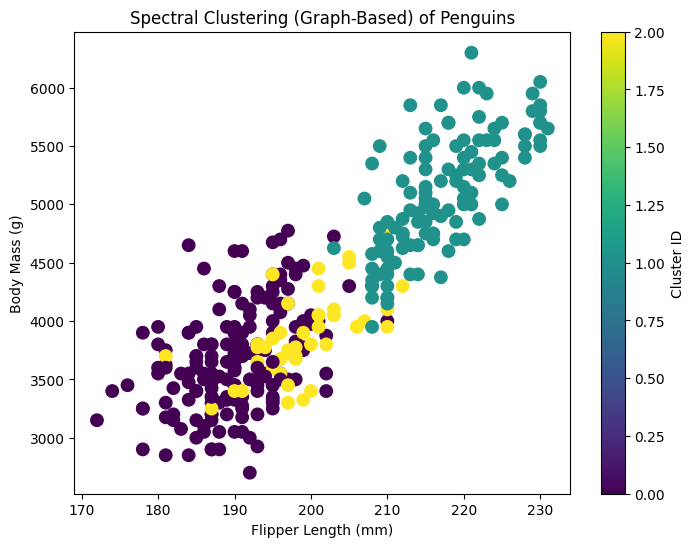

In [34]:
# visualization

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    penguins_clustering['flipper_length_mm'],
    penguins_clustering['body_mass_g'],
    c=labels, cmap='viridis', s=80
)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Spectral Clustering (Graph-Based) of Penguins")
plt.colorbar(scatter, label="Cluster ID")
plt.show()

In [36]:
# species distribution in each cluster
print("\nSpecies distribution per Spectral cluster:")
print(pd.crosstab(penguins_clustering['species'], penguins_clustering['spectral_cluster']))


Species distribution per Spectral cluster:
spectral_cluster    0    1   2
species                       
Adelie            146    0   0
Chinstrap          25    0  43
Gentoo              0  119   0


In [ ]:
# confusion matrix

cluster_mapping = penguins_clustering.groupby('kmeans_cluster')['species'].agg(lambda x: x.value_counts().idxmax()).to_dict()
predicted_species = penguins_clustering['kmeans_cluster'].map(cluster_mapping)
cm_kmeans = pd.crosstab(penguins_clustering['species'], predicted_species)

cluster_mapping = penguins_clustering.groupby('spectral_cluster')['species'].agg(lambda x: x.value_counts().idxmax()).to_dict()
predicted_species = penguins_clustering['spectral_cluster'].map(cluster_mapping)
cm_spectral = pd.crosstab(penguins_clustering['species'], predicted_species)

# visualisation
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Kmeans clusters
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="OrRd", ax=axes[0])
axes[0].set_title("Confusion Matrix: K-Means Clustering")
axes[0].set_xlabel("Predicted Species (clusters)")
axes[0].set_ylabel("True Species")

# GMM clusters
sns.heatmap(cm_gmm, annot=True, fmt="d", cmap="OrRd", ax=axes[1])
axes[1].set_title("Confusion Matrix: Gaussian Mixture Models")
axes[1].set_xlabel("Predicted Species (clusters)")
axes[1].set_ylabel("True Species")

# Spectral clusters
sns.heatmap(cm_spectral, annot=True, fmt="d", cmap="OrRd", ax=axes[2])
axes[2].set_title("Confusion Matrix: Spectral Clustering")
axes[2].set_xlabel("Predicted Species (clusters)")
axes[2].set_ylabel("True Species")

plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

:::{callout} Spectral Clustering *vs.* Gaussian Mixture Models *vs.* K-Means
- from confusion matrix shown above, it seems that Spectral clustering and K-Means models are less effective than GMM model on Penguins dataset, main reasons may attribute to
- small dataset size
	- Penguins dataset has only 333 samples
	- spectral clustering computes eigenvectors of similarity matrix, which can be less stable with small datasets, leading to variability in cluster assignments
- small number of features/low dimensionality
	- Penguins dataset typically uses only 4 numerical features, and in such low-dimensional, fairly well-separated data, simpler methods like K-Means or GMM often perform just as well or better
	- Spectral clustering shines when clusters are non-convex or complexly shaped in high-dimensional spaces
</div>

### 7.3 <mark>**Spectral Clustering vs. K-Means models on the Two-Moon Dataset**</mark>

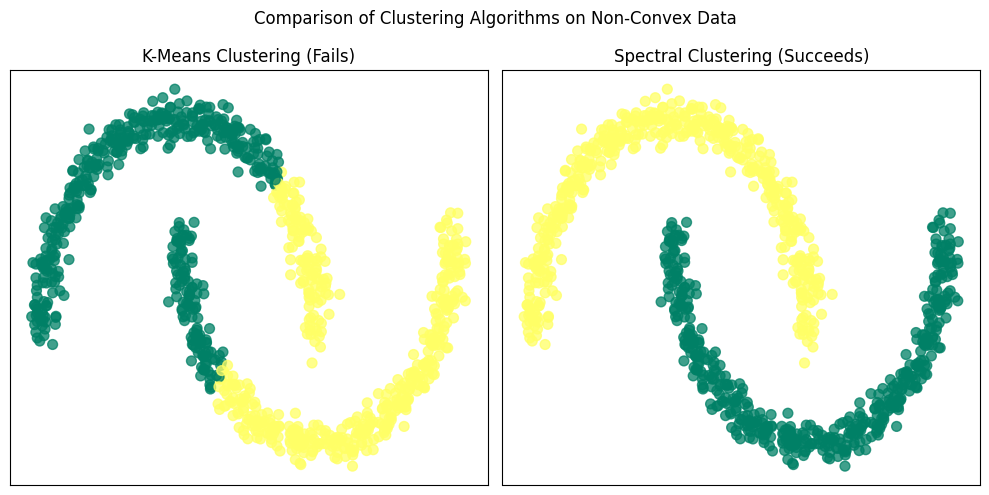

In [38]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, SpectralClustering

# generate the "two moons" dataset
X, y = make_moons(n_samples=1000, noise=0.05, random_state=0)

# K-Means will fail because the clusters are not spherical
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

# Spectral Clustering will succeed because it sees the connectivity.
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=30, random_state=0)
y_spectral = spectral.fit_predict(X)

# visualize the results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# plot K-Means results
axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='summer', alpha=0.75)
axes[0].set_title('K-Means Clustering (Fails)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# plot Spectral Clustering results
axes[1].scatter(X[:, 0], X[:, 1], c=y_spectral, s=50, cmap='summer', alpha=0.75)
axes[1].set_title('Spectral Clustering (Succeeds)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle('Comparison of Clustering Algorithms on Non-Convex Data')
plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

**Spectral Clustering excels for datasets with complex, non-convex cluster shapes, where traditional algorithms like K-Means may fail to capture true underlying structure**.
</div>

## 8. Comparison of Clustering Algorithms

In [51]:
model_names = ['Spectral Clustering', 'Gaussian Mixture Models', 'DBSCAN', 
               'Hierarchical Clustering (SkLearn)',
               'Hierarchical Clustering (SciPy)', 'K-Means Clustering']

sil_accuracy_scores = [sil_score_spectral, sil_score_gmm, sil_score_dbscan,
                       sil_score_hier_aggl, sil_score_hier_scipy, penguins_kmeans_sil_scores]

ari_accuracy_scores = [ari_score_spectral, ari_score_gmm, ari_score_dbscan,
                       ari_score_hier_aggl, ari_score_hier_scipy, penguins_kmeans_sil_scores]

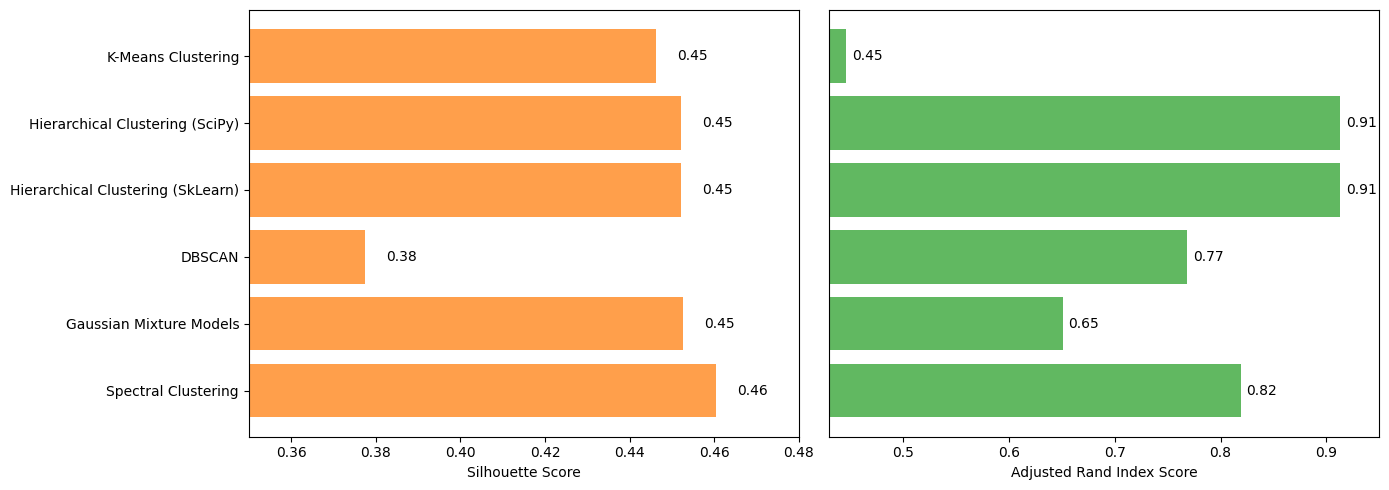

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# silhouette scores
axes[0].barh(model_names, sil_accuracy_scores, color='tab:orange', alpha=0.75)
axes[0].set_xlabel('Silhouette Score')
axes[0].set_xlim(0.35, 0.48)
for i, score in enumerate(sil_accuracy_scores):
    axes[0].text(score + 0.005, i, f'{score:.2f}', va='center')

# adjusted rand index scores
axes[1].barh(model_names, ari_accuracy_scores, color='tab:green', alpha=0.75)
axes[1].set_xlabel('Adjusted Rand Index Score')
axes[1].set_xlim(0.43, 0.95)
axes[1].set_yticks([])
for i, score in enumerate(ari_accuracy_scores):
    axes[1].text(score + 0.005, i, f'{score:.2f}', va='center')

plt.tight_layout()
plt.show()

## 9. Summary

| Method | Type/Approach | Key Characteristics | Pros | Limitations |
| :----: | :----: | :----: | :----: | :----: |
| K-Means | Centroid-based | Partitions data into <br>*k* clusters by minimizing <br>within-cluster variance; <br>clusters represented by centroids | Simple, fast, widely used; <br>interpretable | Assumes spherical clusters; <br>sensitive to initialization and outliers; <br>requires specifying *k* |
| Hierarchical Clustering <br>(SciPy) | Tree-based | Similar to Scikit-Learn, <br>uses linkage matrix <br>and fcluster to assign clusters | Flexible; supports different <br>distance metrics and linkage methods | Requires careful selection of <br>threshold to cut dendrogram; <br>can be slow for large data |
| Hierarchical Clustering <br>(Scikit-Learn) | Tree-based | Builds a hierarchy of clusters <br>either bottom-up (agglomerative) <br>or top-down (divisive); <br>linkage criteria define <br>merge/split decisions | Dendrogram visualization; <br>no need to pre-specify number of clusters | Computationally expensive for large datasets; <br>choice of linkage affects results |
| DBSCAN | Density-based | Groups points <br>based on density; identifies core, <br>border, and noise points; <br>no need to specify number of clusters | Detects arbitrarily shaped clusters; <br>robust to outliers; <br>identifies noise | Sensitive to eps and min_samples; <br>struggles with varying densities |
| GMM | Model-based | Assumes data generated from <br>a mixture of Gaussian distributions; <br>each cluster has mean, <br> covariance, and weight | Can model elliptical clusters; <br>provides probabilities for cluster membership | Sensitive to initialization; <br>may converge to local optima; <br>assumes Gaussian distribution |
| Spectral Clustering | Graph-based | Uses graph Laplacian of similarity matrix; <br>clusters derived from eigenvectors; <br>can handle non-convex shapes | Captures complex structures; <br>good for connected or non-spherical clusters | Computationally expensive for large datasets; <br>sensitive to affinity and connectivity; <br>may fail on disconnected graphs |

<div class='alert alert-info'>

:::{keypoints}
- Clustering is about grouping data points that are similar to each other, without using labels.
- Representative algorithms for clustering tasks: K-Means (centroid-based), Hierarchical, DBSCAN (density-based), Gaussian Mixture Models (model-based), and Spectral Clustering (graph-based).
- Use tools like Silhouette score or visual plots to see how well clusters are separated.
- **No single algorithm is "best", and the right method depends on your data: size, type, shape, and what you want to achieve**.
:::
</div>